In [1]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
import zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import defaultdict, Counter
import imagehash

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip "/content/drive/MyDrive/Parkinson's Dataset Final.zip" -d /content/dataset

Archive:  /content/drive/MyDrive/Parkinson's Dataset Final.zip
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/
   creating: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Meander_HandPD/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Spiral_HandPD/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Meander_HandPD/healthy/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Meander_HandPD/parkinson/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Spiral_HandPD/healthy/
   creating: /content/dataset/Parkinson's Dataset Final/Hand Pd/Spiral_HandPD/parkinson/
   creating: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Healthy/
   creating: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Parkinson's/
   creating: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Healthy/HealthyCircle/
   creati

In [5]:
BASE = "/content/dataset/Parkinson's Dataset Final/Hand Pd"

SPIRAL = os.path.join(BASE,"Spiral_HandPD")
MEANDER = os.path.join(BASE,"Meander_HandPD")

paths=[]
labels=[]

def collect(root):

    for cls in os.listdir(root):

        cls_path=os.path.join(root,cls)

        if cls.lower()=="healthy":
            lab=0
        elif cls.lower()=="parkinson":
            lab=1
        else:
            continue

        for r,d,files in os.walk(cls_path):

            for f in files:

                if f.endswith((".png",".jpg",".jpeg",".bmp")):

                    paths.append(os.path.join(r,f))
                    labels.append(lab)

collect(SPIRAL)
collect(MEANDER)

print("Total images:",len(paths))
print("Distribution:",Counter(labels))

Total images: 808
Distribution: Counter({1: 592, 0: 216})


In [6]:
def get_hash(p):

    try:
        img=Image.open(p).convert("L").resize((224,224))
        return imagehash.phash(img)
    except:
        return None

hash_map=defaultdict(list)

for p in tqdm(paths):

    h=get_hash(p)

    if h:
        hash_map[str(h)].append(p)

clean_paths=[]
clean_labels=[]

path_label=dict(zip(paths,labels))

for h in hash_map:

    p=hash_map[h][0]

    clean_paths.append(p)
    clean_labels.append(path_label[p])

print("Clean images:",len(clean_paths))

100%|██████████| 808/808 [00:08<00:00, 96.70it/s] 

Clean images: 735


In [7]:
paths=np.array(clean_paths)
labels=np.array(clean_labels)

train_paths,test_paths,y_train,y_test=train_test_split(
paths,labels,test_size=0.2,stratify=labels,random_state=42
)

val_paths,test_paths,y_val,y_test=train_test_split(
test_paths,y_test,test_size=0.5,stratify=y_test,random_state=42
)

print("Train:",Counter(y_train))
print("Val:",Counter(y_val))
print("Test:",Counter(y_test))

Train: Counter({np.int64(1): 473, np.int64(0): 115})
Val: Counter({np.int64(1): 59, np.int64(0): 14})
Test: Counter({np.int64(1): 59, np.int64(0): 15})


In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.5565217391304347), 1: np.float64(0.6215644820295984)}


In [10]:
IMG_SIZE=224
BATCH=16

def preprocess(path):

    path=path.numpy().decode()

    img=cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    clahe=cv2.createCLAHE(2.0,(8,8))
    img=clahe.apply(img)

    img=img/255.0
    img=np.expand_dims(img,-1)

    return img.astype(np.float32)

def tf_preprocess(path,label):

    img=tf.py_function(preprocess,[path],tf.float32)
    img.set_shape((IMG_SIZE,IMG_SIZE,1))

    return img,label

In [11]:
def make_ds(paths,labels):

    ds=tf.data.Dataset.from_tensor_slices((paths,labels))

    ds=ds.shuffle(1000)

    ds=ds.map(tf_preprocess,num_parallel_calls=tf.data.AUTOTUNE)

    ds=ds.batch(BATCH)

    ds=ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds=make_ds(train_paths,y_train)
val_ds=make_ds(val_paths,y_val)
test_ds=make_ds(test_paths,y_test)

In [12]:
from tensorflow.keras import layers
from tensorflow import keras

def build_model():

    inputs=layers.Input((224,224,1))

    # CNN Feature Extractor
    x=layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    x=layers.MaxPooling2D()(x)

    x=layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x=layers.MaxPooling2D()(x)

    x=layers.Conv2D(128,3,activation='relu',padding='same')(x)

    # Patch embedding
    x=layers.Conv2D(128,16,strides=16)(x)

    x=layers.Reshape((-1,128))(x)

    # Transformer block
    attn=layers.MultiHeadAttention(num_heads=4,key_dim=32)(x,x)

    x=layers.Add()([x,attn])
    x=layers.LayerNormalization()(x)

    ffn=layers.Dense(256,activation="gelu")(x)
    ffn=layers.Dense(128)(ffn)

    x=layers.Add()([x,ffn])
    x=layers.LayerNormalization()(x)

    x=layers.GlobalAveragePooling1D()(x)

    x=layers.Dense(128,activation='relu')(x)

    outputs=layers.Dense(2,activation='softmax')(x)

    model=keras.Model(inputs,outputs)

    return model

model=build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 3, 3, 128) │  4,194,432 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 9, 128)    │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 128)    │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9, 128)    │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        258 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,436,354 (16.92 MB)

 Trainable params: 4,436,354 (16.92 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
optimizer=tf.keras.optimizers.Adam(1e-4),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [14]:
early=tf.keras.callbacks.EarlyStopping(
monitor="val_loss",
patience=6,
restore_best_weights=True
)

history=model.fit(
train_ds,
validation_data=val_ds,
epochs=40,
class_weight=class_weights,
callbacks=[early]
)

Epoch 1/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.4673 - loss: 0.9305 - val_accuracy: 0.8082 - val_loss: 0.5582
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.6645 - loss: 0.7215 - val_accuracy: 0.8082 - val_loss: 0.6490
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.4550 - loss: 0.7019 - val_accuracy: 0.1918 - val_loss: 0.7343
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.3287 - loss: 0.7170 - val_accuracy: 0.8082 - val_loss: 0.5029
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.5118 - loss: 0.7659 - val_accuracy: 0.8082 - val_loss: 0.5585
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.4743 - loss: 0.7464 - val_accuracy: 0.8082 - val_loss: 0.5827
Epoch 7/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.6535 - loss: 0.6814 - val_accuracy: 0.8082 - val_loss: 0.6051
Epoch 8/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - accuracy: 0.5393 - loss: 0.7200 - val_accuracy: 0

In [15]:
model.evaluate(test_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 791ms/step - accuracy: 0.8279 - loss: 0.6157


[0.4952329695224762, 0.837837815284729]

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 742ms/step


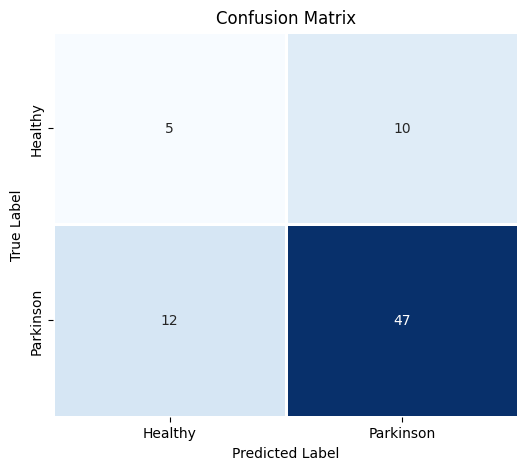

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predictions
pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    xticklabels=["Healthy","Parkinson"],
    yticklabels=["Healthy","Parkinson"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

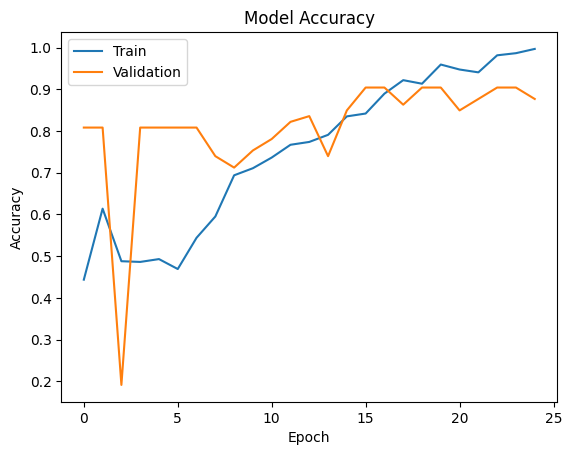

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test_ds)

# change threshold
threshold = 0.6

y_pred = (pred[:,1] > threshold).astype(int)

y_true = np.concatenate([y for x,y in test_ds], axis=0)

print(confusion_matrix(y_true,y_pred))
print(classification_report(y_true,y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
[[ 2 13]
 [16 43]]
              precision    recall  f1-score   support

           0       0.11      0.13      0.12        15
           1       0.77      0.73      0.75        59

    accuracy                           0.61        74
   macro avg       0.44      0.43      0.43        74
weighted avg       0.63      0.61      0.62        74



In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test_ds)

threshold = 0.7

y_pred = (pred[:,1] > threshold).astype(int)

y_true = np.concatenate([y for x,y in test_ds], axis=0)

print(confusion_matrix(y_true,y_pred))
print(classification_report(y_true,y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
[[ 7  8]
 [12 47]]
              precision    recall  f1-score   support

           0       0.37      0.47      0.41        15
           1       0.85      0.80      0.82        59

    accuracy                           0.73        74
   macro avg       0.61      0.63      0.62        74
weighted avg       0.76      0.73      0.74        74



5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step

===== Final Performance Summary =====

Test Accuracy        : 64.86%
Healthy Recall       : 26.67%
Parkinson Recall     : 74.58%
Parkinson Precision  : 80.00%

Confusion Matrix:
[[ 4 11]
 [15 44]]


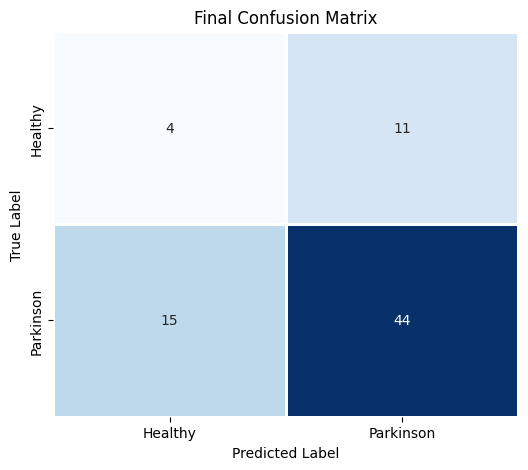

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

pred = model.predict(test_ds)

threshold = 0.65
y_pred = (pred[:,1] > threshold).astype(int)

y_true = np.concatenate([y for x,y in test_ds], axis=0)


cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)
accuracy = accuracy_score(y_true, y_pred)

healthy_recall = report['0']['recall']
parkinson_recall = report['1']['recall']
parkinson_precision = report['1']['precision']

print("\n===== Final Performance Summary =====\n")

print(f"Test Accuracy        : {accuracy*100:.2f}%")
print(f"Healthy Recall       : {healthy_recall*100:.2f}%")
print(f"Parkinson Recall     : {parkinson_recall*100:.2f}%")
print(f"Parkinson Precision  : {parkinson_precision*100:.2f}%")

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    xticklabels=["Healthy","Parkinson"],
    yticklabels=["Healthy","Parkinson"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix")

plt.show()


===== Final Performance Summary =====

Test Accuracy: 83.78%

Confusion Matrix:
[[10  5]
 [ 7 52]]

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.67      0.62        15
           1       0.91      0.88      0.90        59

    accuracy                           0.84        74
   macro avg       0.75      0.77      0.76        74
weighted avg       0.85      0.84      0.84        74



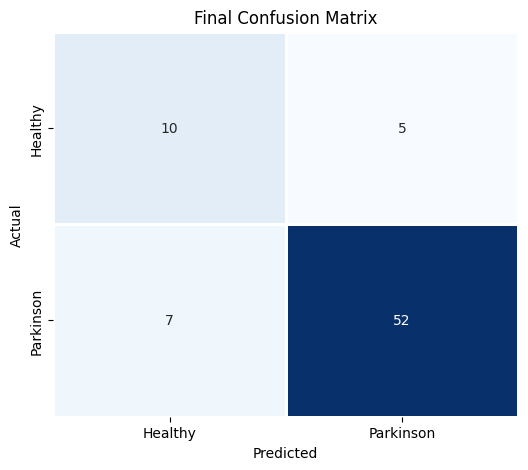

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Collect predictions and true labels in the SAME loop
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Metrics
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\n===== Final Performance Summary =====\n")
print(f"Test Accuracy: {acc*100:.2f}%\n")

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    xticklabels=["Healthy","Parkinson"],
    yticklabels=["Healthy","Parkinson"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")

plt.show()